In [35]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

import math

from sklearn.linear_model import LinearRegression, Ridge, Lasso

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [36]:
# spark = (
#     pyspark
#     .sql
#     .SparkSession
#     .builder
#     .appName('sparksession')
#     .config("spark.driver.memory", "8g")
#     .config("spark.executor.memory", "16g")
#     .config("spark.executor.cores", "4")
#     .config("spark.network.timeout", "600s") \
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [37]:
ticker = 'SPY'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="second", from_="2022-10-16", to="2024-12-30", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)

12467833it [05:33, 37364.24it/s]


In [39]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']
ticker_hist['Returns'] = ticker_hist['Close'] - ticker_hist['Open']


times = pd.DataFrame(ticker_hist['Time'].unique())
times.columns = ['Time']
times['Time'] = times['Time'].sort_values().reset_index(drop = True)

ab_params = {}

for i in range(10):
    ab_params[f'moment_{i}'] = {}

ab_params['autocorr_slope'] = {}
ab_params['autocorr_intercept'] = {}

print('analyzing')

dates = ticker_hist['Date'].unique()

autocorrs = []
for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]

    #ticker_hist_date = pd.merge(left = times, right = ticker_hist_date, on = "Time", how = "outer")
    #ticker_hist_date = ticker_hist_date.sort_values(by = 'Time').reset_index(drop = True)
    #ticker_hist_date = ticker_hist_date.ffill()

    ticker_hist_date['logReturns'] = ticker_hist_date['logClose'] - ticker_hist_date['logOpen']
    ticker_hist_date['logReturns_shifted'] = ticker_hist_date['logReturns'].shift(-1)

    autocorr_calc = ticker_hist_date[['logReturns', 'logReturns_shifted']].dropna()

    lr = LinearRegression()

    lr.fit(
        autocorr_calc['logReturns'].values.reshape(-1, 1),
        autocorr_calc['logReturns_shifted'].values
    )

    idiosyncratic_returns = lr.predict(autocorr_calc['logReturns'].values.reshape(-1, 1))

    noise_returns = autocorr_calc['logReturns_shifted'] - idiosyncratic_returns

    for i in range(10):
        ab_params[f'moment_{i}'][date] = np.mean(noise_returns ** i)

    ab_params['autocorr_slope'][date] = lr.coef_[0]
    ab_params['autocorr_intercept'][date] = lr.intercept_

analyzing


0it [00:00, ?it/s]/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_1509/3484989733.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ticker_hist_date['logReturns'] = ticker_hist_date['logClose'] - ticker_hist_date['logOpen']
/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_1509/3484989733.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ticker_hist_date['logReturns_shifted'] = ticker_hist_date['logReturns'].shift(-1)
1it [00:00,  2.83it/s]/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm00

In [42]:
ab_params_df = pd.DataFrame(ab_params)

In [43]:
ab_params_df

,moment_0,moment_1,moment_2,moment_3,moment_4,moment_5,moment_6,moment_7,moment_8,moment_9,autocorr_slope,autocorr_intercept
2022-10-17,1.0,2.145583e-22,3.970394e-09,-5.591906e-14,2.272610e-16,-5.921661e-20,8.394301e-23,-5.752496e-26,6.207726e-29,-5.460748e-32,0.041615,-7.253460e-08
2022-10-18,1.0,-1.157460e-22,5.964994e-09,9.542522e-14,5.464969e-16,3.734907e-19,6.536283e-22,9.118137e-25,1.429950e-27,2.164604e-30,0.029918,-7.901335e-09
2022-10-19,1.0,2.722416e-22,5.024688e-09,7.818450e-14,3.529235e-16,6.173826e-20,1.419852e-22,6.396553e-26,1.047327e-28,6.699356e-32,0.028070,-1.074835e-06
2022-10-20,1.0,1.539240e-22,4.933723e-09,3.324348e-14,2.970909e-16,3.197190e-20,7.938229e-23,2.765906e-26,4.041420e-29,2.342903e-32,0.015212,-3.385854e-07
2022-10-21,1.0,-9.640352e-24,8.799378e-09,-2.047351e-13,9.805666e-16,-4.086653e-20,3.894530e-22,7.027556e-26,2.945356e-28,1.612967e-31,0.017953,-2.356940e-07
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,1.0,7.216388e-23,2.401352e-09,-2.307272e-12,7.871656e-15,-2.623619e-17,8.922587e-20,-3.042180e-22,1.039306e-24,-3.552814e-27,-0.002163,-5.519729e-07
2024-12-24,1.0,-6.650272e-22,9.411580e-10,1.008793e-13,1.010678e-16,8.339772e-20,7.904362e-23,7.499377e-26,7.199089e-29,6.922840e-32,0.034981,-9.473264e-08
2024-12-26,1.0,6.294768e-22,7.636244e-10,-5.090604e-15,1.104380e-17,3.725618e-22,6.481792e-25,1.048098e-28,7.179780e-32,1.990283e-35,0.023003,-9.780354e-07
2024-12-27,1.0,1.387409e-22,1.998418e-09,3.226131e-14,9.697109e-17,-2.414210e-21,3.717212e-23,-8.576105e-27,2.227308e-29,-8.887867e-33,0.028314,7.998723e-08


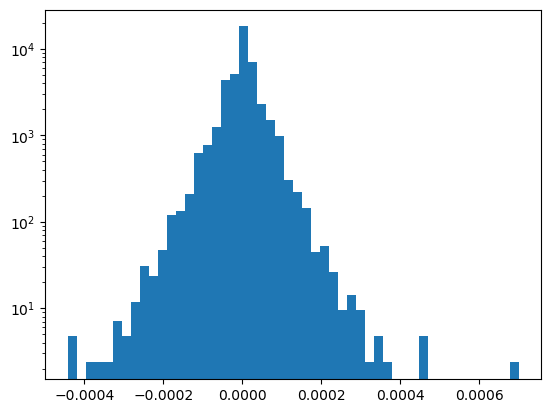

In [44]:
plt.hist(noise_returns, bins = 50, density = True)
plt.yscale('log')
plt.show()

In [45]:
scipy.stats.spearmanr(ab_params_df['moment_9'].iloc[:-1], ab_params_df['moment_9'].shift(-1).iloc[:-1])

SignificanceResult(statistic=np.float64(0.13761519123582988), pvalue=np.float64(0.0011774890473026163))

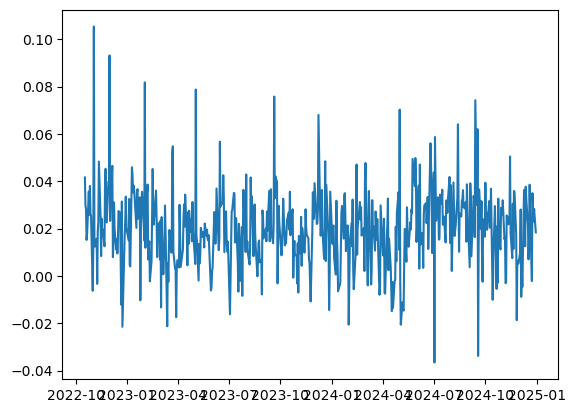

In [46]:
plt.plot(ab_params_df['autocorr_slope'])


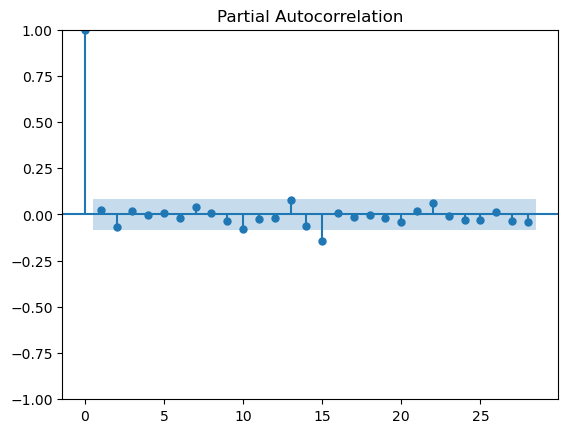

In [59]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['moment_3']
)
plt.show()

In [48]:
noise_returns.mean()

np.float64(-5.607035961784648e-22)

In [49]:
np.arange(-1, 1, 0.00001).shape

(200000,)

In [23]:
lambdas = np.random.randn(10)

In [26]:
x = np.arange(-1, 1, 0.00001)
exp_argument = np.zeros((10, x.shape[0]))
for i in range(10):
    exp_argument[i] = x ** i

In [31]:
np.sum(lambdas.reshape(10,-1) * exp_argument, axis=0)

array([-1.64713455, -1.64696642, -1.6467983 , ...,  0.26719347,
        0.26726655,  0.26733964])

In [24]:
lambdas * 

array([-0.09623218,  0.538529  ,  0.56977486, -0.84248414, -0.18094341,
       -1.35889845, -1.34611129,  1.36786186,  0.36365112,  1.25226538])

In [63]:
class MaxEntFit():
    def __init__(
        self,
        num_moments: int,
        discretisation: float = 0.00001,
        lower_bound: float = -1.,
        upper_bound: float = 1.
    ):
        """
        Initialize the distribution for max ent fitting, selecting the upper and lower
        bounds for the integration of the model and the number of moments I'd like to fit.
        """
        self.num_moments = num_moments
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.discretisation = discretisation
        self.num_datapoints = math.ceil(
            (self.upper_bound - self.lower_bound) / self.discretisation
        )
        
        self.lambdas = np.random.randn(
            self.num_moments
        ).reshape(
            self.num_moments, -1
        )
        
        self.x = np.arange(lower_bound, upper_bound, discretisation)
        
    def moment_evaluator(self):
        exp_arguments = np.zeros(
            (self.num_moments, self.num_datapoints)
        )

        for moment in range(self.num_moments):
            exp_arguments[i] = self.x ** moment
        exp_arguments = np.sum(self.lambdas * exp_arguments, axis = 0)
        integrand = np.exp(exp_arguments)
        partition_function = np.sum(integrand * self.discretisation)

        theoretical_moments = np.zeros(self.num_moments)

        for moment in range(self.num_moments):
            integrand = (self.x ** moment) * np.exp(exp_arguments)
            theoretical_moments[moment] = np.sum(integrand * self.discretisation)/partition_function

        return theoretical_moments

In [64]:
test = MaxEntFit(10)

In [65]:
test.moment_evaluator()

array([1.        , 0.12105004, 0.35786099, 0.103468  , 0.22695348,
       0.09046735, 0.16949689, 0.08044711, 0.13675355, 0.07247734])

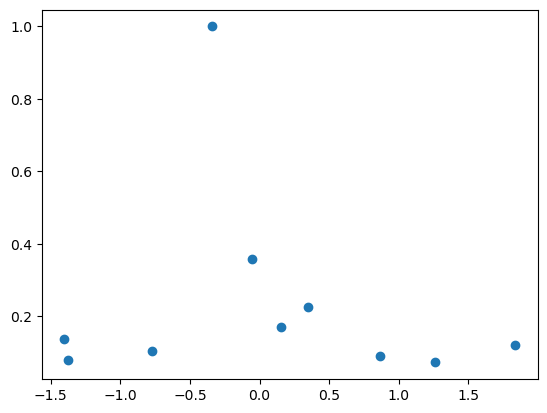

In [67]:
plt.scatter(test.lambdas.reshape(10,), test.moment_evaluator())

In [7]:
ab_params_df = pd.DataFrame(ab_params)

In [8]:
ab_params_df

,moment_0,moment_1,moment_2,moment_3,moment_4,moment_5,moment_6,moment_7,moment_8,moment_9,autocorr_slope,autocorr_intercept
2023-02-15,1.0,-7.418421e-23,1.997716e-09,-1.388147e-14,1.673310e-16,-1.638894e-21,8.568501e-23,-2.000315e-27,6.306918e-29,-4.584824e-33,0.245343,4.099842e-07
2023-02-16,1.0,-1.483684e-22,2.750378e-09,3.553854e-13,1.065130e-15,1.790763e-18,4.053954e-21,8.349014e-24,1.799292e-26,3.802447e-29,0.217966,-1.587353e-07
2023-02-17,1.0,-7.418421e-23,1.978665e-09,-3.377077e-15,7.695628e-17,4.901961e-21,1.509277e-23,2.742312e-27,5.201624e-30,1.425898e-33,0.220551,9.237495e-09
2023-02-21,1.0,-1.530049e-22,1.746618e-09,-1.118565e-13,2.694068e-16,-1.832026e-19,2.974818e-22,-2.883893e-25,4.036164e-28,-4.363383e-31,0.190078,-4.184594e-07
2023-02-22,1.0,-9.273026e-23,3.109455e-09,-4.459942e-14,6.902610e-16,2.751620e-19,1.036303e-21,1.002578e-24,2.303181e-27,2.927124e-30,0.212861,-4.792204e-08
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-11,1.0,1.854605e-23,6.311549e-10,1.378954e-15,6.131017e-18,3.037309e-22,2.486645e-25,4.244402e-29,2.051165e-32,5.508932e-36,0.120072,3.868336e-07
2024-12-12,1.0,3.709210e-23,6.380935e-10,-1.596029e-15,8.847786e-18,-1.477648e-22,6.269230e-25,-1.967010e-29,7.599333e-32,-2.495159e-36,0.140869,-6.440279e-08
2024-12-13,1.0,6.491118e-23,1.050186e-09,-8.447709e-15,1.496015e-17,-5.873369e-22,7.290630e-25,-7.623248e-29,6.105252e-32,-1.100992e-35,0.130510,-2.578377e-08
2024-12-16,1.0,0.000000e+00,1.210432e-09,-7.344915e-15,2.068555e-17,4.537380e-22,1.395346e-24,2.212739e-28,1.869959e-31,5.725833e-35,0.072290,3.749632e-07


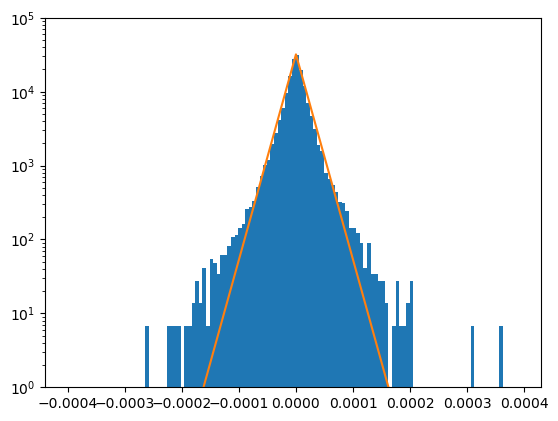

In [90]:
plt.hist(noise_returns, bins = 100, density = True)

plt.plot(
    np.arange(-0.0004, 0.0004, 0.00001),
    1 / (2*b) * np.exp(
        - np.abs(
            np.arange(-0.0004, 0.0004, 0.00001) - a
        )/(b)
    )
)
plt.ylim(10**0, 10**5)
plt.yscale('log')
plt.show()

In [91]:
ab_params_df = pd.DataFrame(ab_params)

In [92]:
ab_params_df

,a,b,autocorr_slope,autocorr_intercept
2023-02-15,1.460366e-07,0.000025,0.245343,4.099842e-07
2023-02-16,-1.527641e-07,0.000029,0.217966,-1.587353e-07
2023-02-17,4.044976e-07,0.000026,0.220551,9.237495e-09
2023-02-21,3.521934e-07,0.000023,0.190078,-4.184594e-07
2023-02-22,8.702898e-07,0.000030,0.212861,-4.792204e-08
...,...,...,...,...
2024-12-05,-3.334272e-08,0.000013,0.139525,-1.058377e-07
2024-12-06,-5.360765e-08,0.000013,0.146488,2.692630e-07
2024-12-09,-1.736574e-08,0.000017,0.133725,-2.134194e-07
2024-12-10,-3.802440e-07,0.000017,0.109320,-2.184066e-07


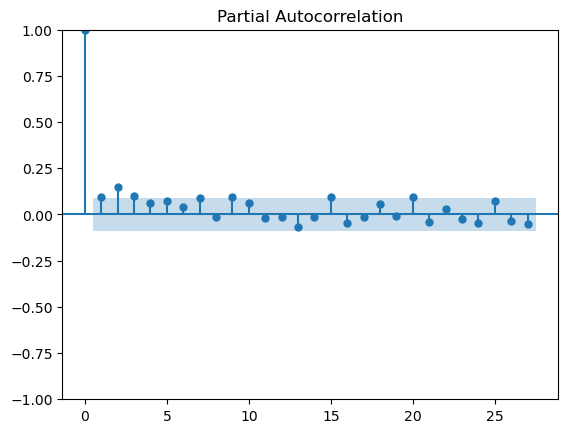

In [93]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a']
)
plt.show()

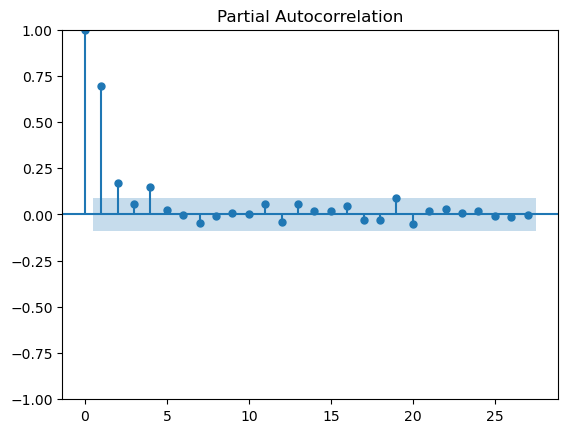

In [94]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b']
)
plt.show()

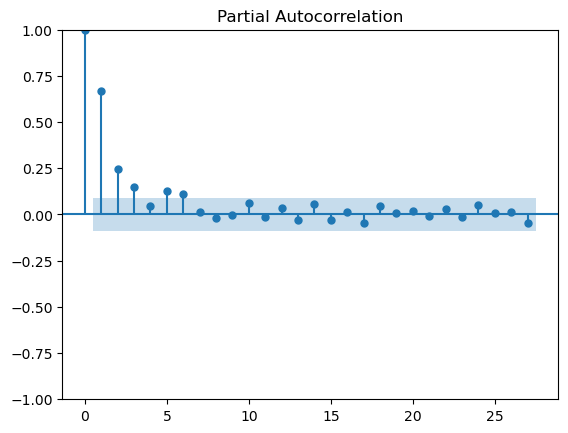

In [95]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['autocorr_slope']
)
plt.show()

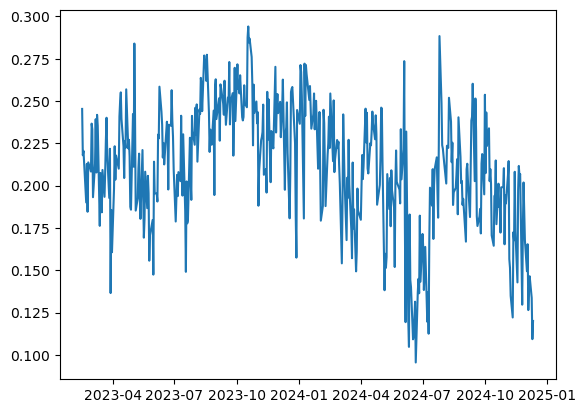

In [96]:
plt.plot(ab_params_df['autocorr_slope'])

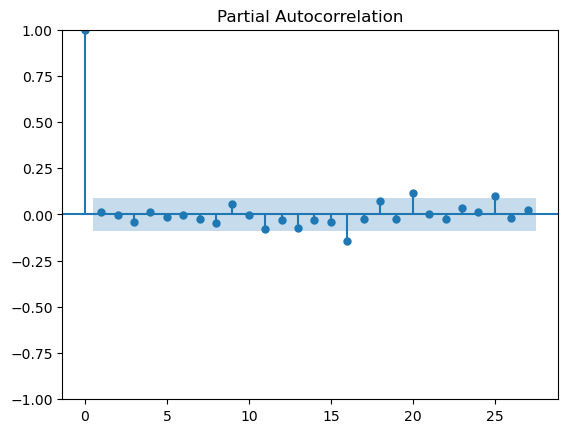

In [97]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['autocorr_intercept']
)
plt.show()

In [98]:
scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['autocorr_slope'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.06965853448635898), pvalue=np.float64(0.13748526544119682))

In [99]:
scipy.stats.pearsonr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['autocorr_slope'].iloc[:-1])

PearsonRResult(statistic=np.float64(0.03782953629466426), pvalue=np.float64(0.4203067839804048))

In [100]:
ab_params_df['shifted_a_1'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b_1'] = ab_params_df['b'].shift(-1)
ab_params_df['shifted_autocorr_slope'] = ab_params_df['autocorr_slope'].shift(-1)
ab_params_df['shifted_autocorr_intercept'] = ab_params_df['autocorr_intercept'].shift(-1)

In [101]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_b_1'])
print(lr_b.score(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_b_1']))

lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_a_1'])
print(lr_a.score(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_a_1']))

lr_autocorr_slope = LinearRegression()

lr_autocorr_slope.fit(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_slope'])
print(lr_autocorr_slope.score(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_slope']))

lr_autocorr_intercept = LinearRegression()

lr_autocorr_intercept.fit(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_intercept'])
print(lr_autocorr_intercept.score(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_intercept']))



0.48740440187662337
0.04583909929123109
0.4557254225060411
0.019611232850019866


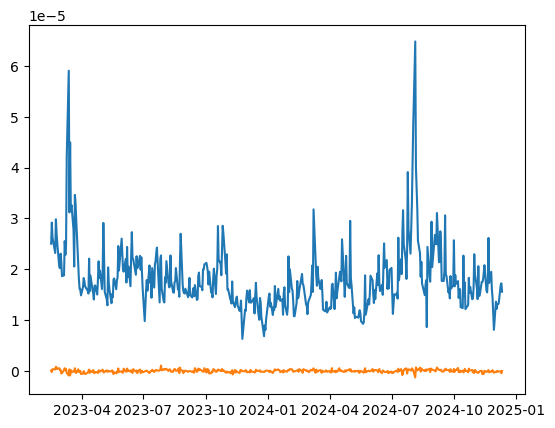

In [102]:
plt.plot(ab_params_df['b'])
plt.plot(ab_params_df['a'])

In [116]:
6.5*3600

23400.0

In [117]:
replicates = 10000
X0 = np.log ( (21763-108) / 21763)

T = np.arange(len(ticker_hist_date)).reshape(len(ticker_hist_date), 1).repeat(replicates, 1)

epsilon = np.random.laplace(
        loc=lr_a.predict(
            ab_params_df[
                ['a', 'b', 'autocorr_slope', 'autocorr_intercept']
            ].dropna()
        )[-1], 
        scale=lr_b.predict(
            ab_params_df[
                ['a', 'b', 'autocorr_slope', 'autocorr_intercept']
            ].dropna()
        )[-1],
        size=(len(ticker_hist_date), replicates)
    )

phi = lr_autocorr_slope.predict(
    ab_params_df[
        ['a', 'b', 'autocorr_slope', 'autocorr_intercept']
    ].dropna()
)[-1]

delta = lr_autocorr_intercept.predict(
    ab_params_df[
        ['a', 'b', 'autocorr_slope', 'autocorr_intercept']
    ].dropna()
)[-1]

In [118]:
lr_a.predict(
            ab_params_df[
                ['a', 'b', 'autocorr_slope', 'autocorr_intercept']
            ].dropna()
        )[-1]

np.float64(5.789982961806578e-08)

In [119]:
possible_daily_returns = []

for r in tqdm(range(replicates)):
    possible = X0.copy()
    last_increment = X0.copy()
    for k in range(len(ticker_hist_date)):
        last_increment = phi * last_increment + delta + epsilon[k, r]
        possible += last_increment
    possible_daily_returns.append(possible)
        

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:07<00:00, 147.90it/s]


In [120]:
possible_daily_returns

[np.float64(-0.003210151070707969),
 np.float64(0.0020767466758818587),
 np.float64(-0.005168993072151392),
 np.float64(0.008154655153079117),
 np.float64(0.0013449674505991785),
 np.float64(-0.006084650921423209),
 np.float64(-0.010675438154684405),
 np.float64(0.0007546011828567269),
 np.float64(-0.010459857078450369),
 np.float64(0.0020521598943469277),
 np.float64(-0.0038240920146632284),
 np.float64(0.0027399949236329665),
 np.float64(-0.0024506955981523277),
 np.float64(-0.0066385746678066715),
 np.float64(-0.012590959811220671),
 np.float64(0.0012345038465876195),
 np.float64(0.0002210979394401939),
 np.float64(0.0009451475482749345),
 np.float64(0.0029588681692593556),
 np.float64(-0.00888918975787381),
 np.float64(-0.0037635752310666228),
 np.float64(-0.00640344679964723),
 np.float64(-0.0006924034231731539),
 np.float64(-0.00027610047997197123),
 np.float64(-0.0038647774745899726),
 np.float64(-0.007532631678842986),
 np.float64(0.0010882843291613485),
 np.float64(-0.00289266

# declare spot ticker price

In [121]:
spot_spx_price = 21763

In [122]:
possible_final_prices = spot_spx_price * np.exp(np.asarray(possible_daily_returns))

In [123]:
print(np.mean(possible_final_prices))
print(np.std(possible_final_prices))

21685.38454099724
91.83279569524036


In [110]:
upper_call = 21720.
lower_call = 21710.
upper_put = 21320.
lower_put = 21310.

In [58]:
payouts = np.zeros(replicates)
for index, price in enumerate(possible_final_prices):
    payout = (
        np.max([0., lower_put - price])
        - np.max([0., upper_put - price])
        - np.max([0., price - lower_call])
        + np.max([0., price - upper_call])
    )

    payouts[index] = payout

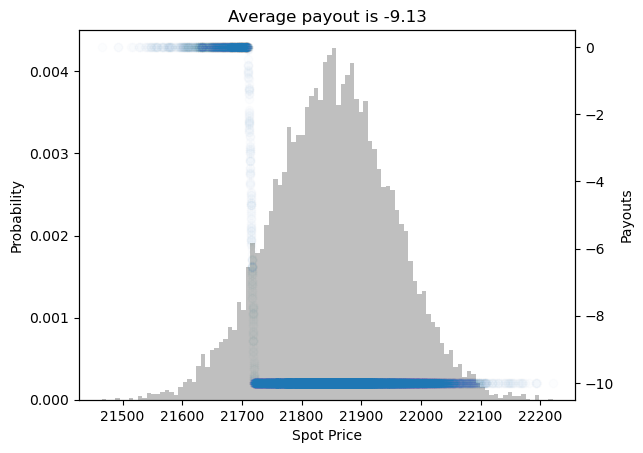

In [59]:
fig, axs = plt.subplots()

axs.hist(possible_final_prices, bins = 100, density = True, alpha=0.5, color = 'grey')
axs.set_ylabel('Probability')
axs.set_xlabel('Spot Price')
#axs.set_title('SPX Price Range, Intra-day, one second predictions')
axs_right = axs.twinx()
#plt.savefig('end_price_distro.pdf', bbox_inches = 'tight')
axs_right.scatter(possible_final_prices, payouts,  alpha=0.01)
axs_right.set_ylabel('Payouts')
mean_payout = np.round(np.mean(payouts), 2)
axs.set_title(f'Average payout is {mean_payout}')
plt.savefig('with_strategy.png', bbox_inches = 'tight')

plt.show()

# compute cost of trade and max loss

In [30]:
cost_of_trade = 2.10
max_loss = 10

In [31]:
p = (max_loss - cost_of_trade)/max_loss

In [32]:
fstar = p - (1-p)/(cost_of_trade/(max_loss-cost_of_trade))
print(f'Kelly Criterion prediction, assuming fair odds, is {fstar}')

Kelly Criterion prediction, assuming fair odds, is 1.1102230246251565e-16


In [33]:
my_p = sum(payouts > -cost_of_trade)/len(payouts)

fstar_me = my_p - (1 - my_p)/(cost_of_trade/(max_loss-cost_of_trade))

print(f'Kelly Criterion prediction, assuming my odds, is {fstar_me}')

Kelly Criterion prediction, assuming my odds, is 0.6880952380952381
